# Phase 3: Demand Forecasting — Hypothesis Testing
**Tiller digital point-of-sale (POS)**  
**BigQuery:** `le-wagon-da-502302.tiller`  
**Date:** September 2026

## Purpose
Phase 2 identified demand forecasting as a strong opportunity. This notebook tests **six hypotheses** under the selected question:

> **Q2:** Can Tiller forecast weekly store-level demand 1–2 weeks ahead using historical patterns?

Flow: **Opportunity → Question → Hypotheses → Analysis → Findings → Product implication**

The aim is not to assume a method. We establish what the data supports, test the strongest hypotheses, and only then decide what complexity is justified.

## Key definitions

| Term | Definition |
|------|------------|
| Transaction demand | Orders recorded for a store in the period analysed |
| Weekly demand | Orders for a store in a calendar week |
| Store level | Measured and evaluated per store |
| Forecast | Estimate using only information available before the forecast period |
| 1-week / 2-week ahead | Next / second next week after the latest available information |
| Baseline | Simple reference method for judging whether complexity helps |
| Missing store-week | Not automatically treated as zero demand |
| Evaluation period | Held-out later period for out-of-sample tests |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline

# Tiller Design System
COLORS = {
    'primary': '#3063E9',
    'black': '#111827',
    'gray': '#4B5563',
    'light': '#9CA3AF',
    'grid': '#E5E7EB',
    'bg': '#FFFFFF',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'text.color': COLORS['black'],
    'font.family': 'sans-serif',
    'grid.color': COLORS['grid'],
    'grid.linewidth': 0.6,
    'grid.alpha': 0.7,
})

_root = Path.cwd()
if _root.name == 'notebooks':
    _root = _root.parent
CHARTS_DIR = _root / 'charts' / '03_demand_forecasting'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, loc='left', color=COLORS['black'], pad=10, fontweight='semibold')
    if xlabel:
        ax.set_xlabel(xlabel, color=COLORS['gray'])
    if ylabel:
        ax.set_ylabel(ylabel, color=COLORS['gray'])
    ax.tick_params(colors=COLORS['gray'])
    ax.spines['left'].set_color(COLORS['grid'])
    ax.spines['bottom'].set_color(COLORS['grid'])
    ax.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)

def save_chart(fig, name):
    path = CHARTS_DIR / name
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    plt.close(fig)
    print(f'  ✓ Saved: charts/03_demand_forecasting/{name}')

## Question stress test (summary)

| Area | Evidence | Implication |
|------|----------|-------------|
| Data availability | 21 stores with >1 year; many with >2 years | Enough history for store-level forecasting |
| Historical signal | Median 1-week lag corr ≈ 0.623; 19/20 stores > 0.3 | Recent demand carries signal |
| Horizon | 1-week WAPE 25.4% vs 2-week 36.7% | Shorter horizon is stronger |
| Store concentration | Store 4151 ~68% of volume | Report store-level and aggregate carefully |
| Calendar | Strong DOW ratios; weak week-of-year alone | Test calendar as hypothesis, don’t assume |
| Missing data | Many stores have sparse calendar days | Missing ≠ zero demand |

**Stress-test conclusion:** Q2 is supported enough to test formally, with conditions (store differences, 4151 weight, baseline-first).

## Six hypotheses

| Hypothesis | Why it matters | Validation approach |
|------------|----------------|---------------------|
| **H1** Historical demand provides predictive signal | Useful forecasts without complex models | 1-week vs 2-week lag, out-of-sample |
| **H2** Multiple historical periods improve accuracy | More history might beat last week | Lag vs smoothing / MA / regression |
| **H3** Calendar features improve forecasts | Calendar may add signal | Historical only vs + calendar |
| **H4** Store volume affects forecastability | Reliability may vary by size | Volume groups vs error |
| **H5** Trend-aware forecasting improves forecasts | Adjust for rising/falling demand | Baseline vs trend-aware |
| **H6** Sudden changes reduce reliability | Confidence should depend on conditions | Stable vs sudden-change WAPE |

**Evaluation principles:** out-of-sample accuracy · store-level consistency · robustness · practical relevance  

Numbers below are from the authoritative Phase 3 forecasting analysis (time-aware evaluation). Charts use the Tiller design system.

## H1 — Historical demand provides predictive signal

**Method:** Previous-week lag (1-week ahead) and two-week lag (2-week ahead), time-aware evaluation.

**Results**

In [2]:
h1 = pd.DataFrame({
    'Horizon': ['1-week ahead', '2-week ahead'],
    'Overall WAPE': [25.4, 36.7],
    'Median store WAPE': [27.9, 35.7],
})
print(h1.to_string(index=False))
print()
print('Lag correlations (aggregate): 1w=0.936 | 2w=0.858 | 3w=0.796 | 4w=0.786')
print('Store-level median 1-week lag corr ≈ 0.623 (19/20 stores > 0.3)')

     Horizon  Overall WAPE  Median store WAPE
1-week ahead          25.4               27.9
2-week ahead          36.7               35.7

Lag correlations (aggregate): 1w=0.936 | 2w=0.858 | 3w=0.796 | 4w=0.786
Store-level median 1-week lag corr ≈ 0.623 (19/20 stores > 0.3)


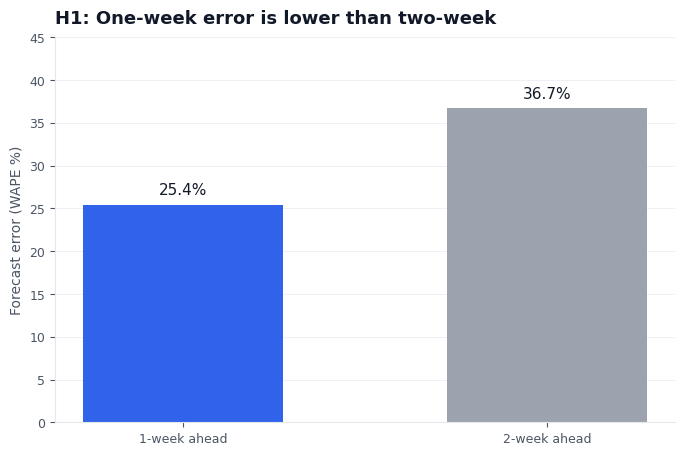

  ✓ Saved: charts/03_demand_forecasting/H1_horizon_comparison.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLORS['primary'], COLORS['light']]
bars = ax.bar(h1['Horizon'], h1['Overall WAPE'], color=colors, edgecolor='none', width=0.55)
ax.set_ylim(0, 45)
style_ax(ax, title='H1: One-week error is lower than two-week', ylabel='Forecast error (WAPE %)')
for i, v in enumerate(h1['Overall WAPE']):
    ax.text(i, v + 1.2, f'{v:.1f}%', ha='center', color=COLORS['black'], fontsize=11)
save_chart(fig, 'H1_horizon_comparison.png')

**Interpretation — SUPPORTED**  
Recent demand is a useful short-term signal. Error rises as the horizon extends (25.4% → 36.7%). Strongest signal is concentrated in the most recent week.

## H2 — Multiple historical periods improve accuracy

**Method:** Same evaluation framework; compare previous-week baseline to smoothing, moving averages, and regression.

In [4]:
h2_1w = pd.DataFrame({
    'Method': [
        'Previous-week baseline',
        'Linear regression',
        'Exp. smoothing α=0.7',
        'Exp. smoothing α=0.5',
        '2-week moving average',
        'Exp. smoothing α=0.3',
        '4-week moving average',
    ],
    'WAPE': [25.4, 26.2, 27.1, 29.1, 29.3, 32.7, 34.3],
})
print('1-week horizon:')
print(h2_1w.to_string(index=False))

1-week horizon:
                Method  WAPE
Previous-week baseline  25.4
     Linear regression  26.2
  Exp. smoothing α=0.7  27.1
  Exp. smoothing α=0.5  29.1
 2-week moving average  29.3
  Exp. smoothing α=0.3  32.7
 4-week moving average  34.3


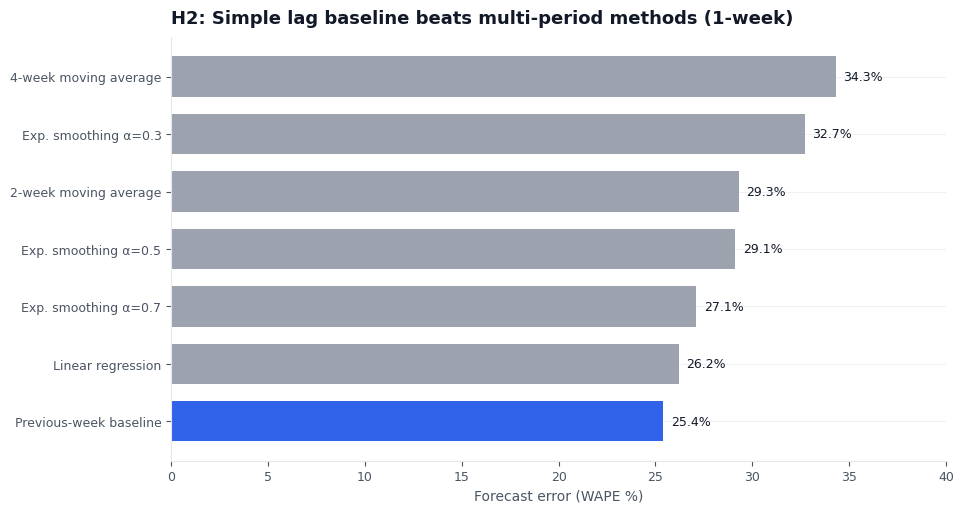

  ✓ Saved: charts/03_demand_forecasting/H2_method_comparison_1w.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
order = h2_1w.sort_values('WAPE', ascending=True)
bar_colors = [COLORS['primary'] if m == 'Previous-week baseline' else COLORS['light'] for m in order['Method']]
ax.barh(order['Method'], order['WAPE'], color=bar_colors, edgecolor='none', height=0.7)
ax.set_xlim(0, 40)
style_ax(ax, title='H2: Simple lag baseline beats multi-period methods (1-week)', xlabel='Forecast error (WAPE %)')
for i, (_, row) in enumerate(order.iterrows()):
    ax.text(row['WAPE'] + 0.4, i, f"{row['WAPE']:.1f}%", va='center', color=COLORS['black'], fontsize=9)
save_chart(fig, 'H2_method_comparison_1w.png')

**Interpretation — NOT SUPPORTED**  
At 1 week, previous-week baseline (25.4%) is best among tested methods. At 2 weeks, two-week lag (36.7%) remains best among valid approaches. No evidence that more historical windows improve accuracy over the simple lag.

## H3 — Calendar features improve forecasts

**Method:** Historical-demand model vs same model + week-of-year, month, holiday-season indicator.

In [6]:
h3_pooled = pd.DataFrame({
    'Forecast': ['Historical only', 'Historical + calendar'],
    'WAPE_1w': [26.2, 27.8],
    'WAPE_2w': [40.7, 42.6],
})
print(h3_pooled.to_string(index=False))
print()
print('Store-level (1-week): 17 of 20 stores improved; 3 worsened (5281, 1513, 7872)')
print('Store 4151 improved (~7.1 pp lower 1-week WAPE)')

             Forecast  WAPE_1w  WAPE_2w
      Historical only     26.2     40.7
Historical + calendar     27.8     42.6

Store-level (1-week): 17 of 20 stores improved; 3 worsened (5281, 1513, 7872)
Store 4151 improved (~7.1 pp lower 1-week WAPE)


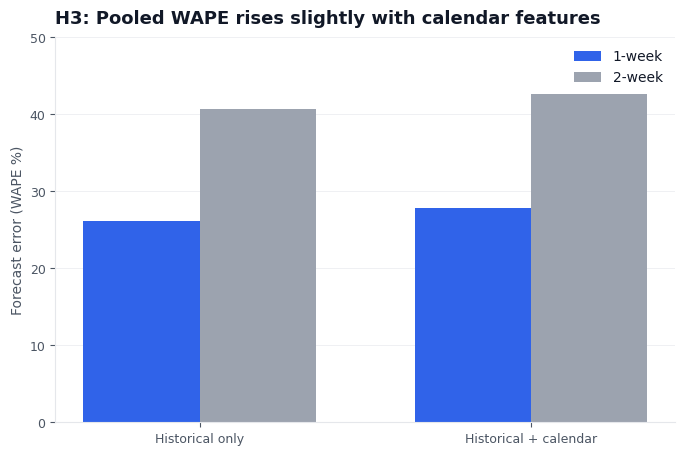

  ✓ Saved: charts/03_demand_forecasting/H3_calendar_pooled.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, h3_pooled['WAPE_1w'], w, label='1-week', color=COLORS['primary'], edgecolor='none')
ax.bar(x + w/2, h3_pooled['WAPE_2w'], w, label='2-week', color=COLORS['light'], edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(h3_pooled['Forecast'])
ax.set_ylim(0, 50)
style_ax(ax, title='H3: Pooled WAPE rises slightly with calendar features', ylabel='Forecast error (WAPE %)')
ax.legend(frameon=False)
save_chart(fig, 'H3_calendar_pooled.png')

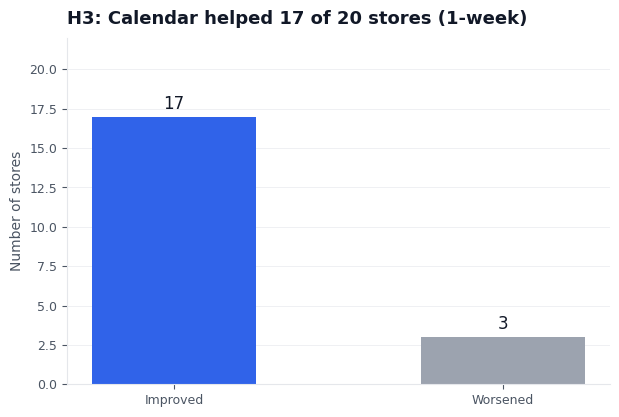

  ✓ Saved: charts/03_demand_forecasting/H3_calendar_store_counts.png


In [8]:
# Store-level message chart
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['Improved', 'Worsened'], [17, 3], color=[COLORS['primary'], COLORS['light']], edgecolor='none', width=0.5)
ax.set_ylim(0, 22)
style_ax(ax, title='H3: Calendar helped 17 of 20 stores (1-week)', ylabel='Number of stores')
for i, v in enumerate([17, 3]):
    ax.text(i, v + 0.5, str(v), ha='center', color=COLORS['black'], fontsize=12)
save_chart(fig, 'H3_calendar_store_counts.png')

**Interpretation — MIXED**  
Pooled WAPE worsens slightly (+1.6 pp at 1 week), but **17/20 stores improve**. Volume weighting (e.g. large stores) can move the aggregate the other way. Evaluate calendar at store level; do not treat it as a universal win.

## H4 — Store volume affects forecastability

**Method:** Training-period mean weekly volume; median split into lower- vs higher-volume groups; test-period WAPE.

In [9]:
h4 = pd.DataFrame({
    'Store group': ['Lower-volume stores', 'Higher-volume stores'],
    'Median WAPE': [28.0, 25.2],
})
print(h4.to_string(index=False))
print('Difference: 2.8 pp')
print('Store 4151 ≈ 6,286 orders/week in training (very high volume)')

         Store group  Median WAPE
 Lower-volume stores         28.0
Higher-volume stores         25.2
Difference: 2.8 pp
Store 4151 ≈ 6,286 orders/week in training (very high volume)


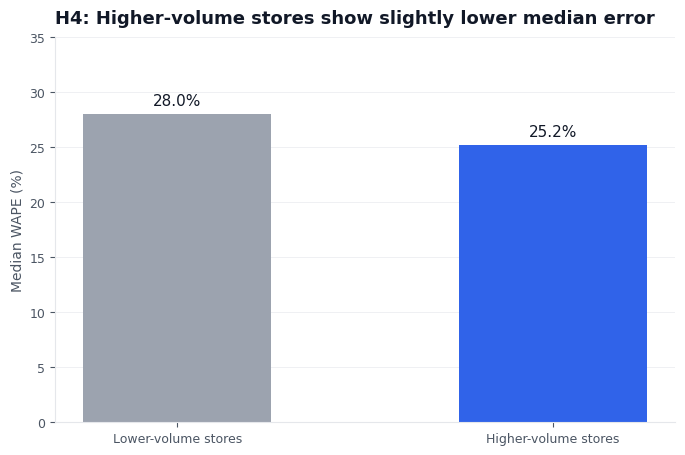

  ✓ Saved: charts/03_demand_forecasting/H4_volume_groups.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLORS['light'], COLORS['primary']]
ax.bar(h4['Store group'], h4['Median WAPE'], color=colors, edgecolor='none', width=0.5)
ax.set_ylim(0, 35)
style_ax(ax, title='H4: Higher-volume stores show slightly lower median error', ylabel='Median WAPE (%)')
for i, v in enumerate(h4['Median WAPE']):
    ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', color=COLORS['black'], fontsize=11)
save_chart(fig, 'H4_volume_groups.png')

**Interpretation — SUPPORTED**  
Higher-volume stores tend to have lower median error (25.2% vs 28.0%). Volume is associated with forecastability but does not fully determine it — similar volumes can still differ.

## H5 — Trend-aware forecasting improves forecasts

**Method:** `forecast = 2×lag_1w − lag_2w` vs previous-week baseline; 1-week horizon; no leakage.

In [11]:
h5 = pd.DataFrame({
    'Approach': ['Historical baseline', 'Trend-aware'],
    'WAPE': [25.4, 33.1],
    'MAE_orders': [91.9, 119.9],
})
print(h5.to_string(index=False))
print('Worse for 19 of 20 stores; Store 4151: 29.0% → 37.6%')

           Approach  WAPE  MAE_orders
Historical baseline  25.4        91.9
        Trend-aware  33.1       119.9
Worse for 19 of 20 stores; Store 4151: 29.0% → 37.6%


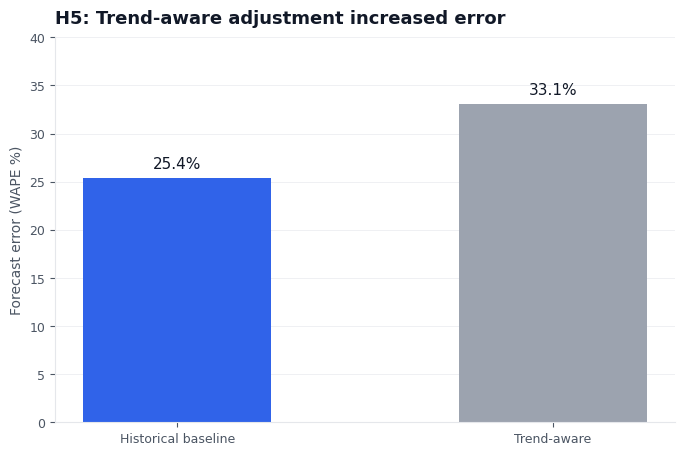

  ✓ Saved: charts/03_demand_forecasting/H5_trend_aware.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLORS['primary'], COLORS['light']]
ax.bar(h5['Approach'], h5['WAPE'], color=colors, edgecolor='none', width=0.5)
ax.set_ylim(0, 40)
style_ax(ax, title='H5: Trend-aware adjustment increased error', ylabel='Forecast error (WAPE %)')
for i, v in enumerate(h5['WAPE']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', color=COLORS['black'], fontsize=11)
save_chart(fig, 'H5_trend_aware.png')

**Interpretation — NOT SUPPORTED**  
The tested trend-aware rule raised overall WAPE from 25.4% to 33.1%. This does not prove every trend method fails — only that this specification did not beat the simple baseline.

## H6 — Sudden demand changes reduce reliability

**Method:** Week-over-week change threshold at 75th percentile (41.9%). Stable ≤ 41.9%; sudden > 41.9%.

In [13]:
h6 = pd.DataFrame({
    'Condition': ['Stable demand', 'Sudden change'],
    'Observations': [430, 144],
    'WAPE': [20.6, 42.9],
})
print(h6.to_string(index=False))
print('Difference: +22.3 pp')
print('17 of 20 stores worse during sudden-change periods')

    Condition  Observations  WAPE
Stable demand           430  20.6
Sudden change           144  42.9
Difference: +22.3 pp
17 of 20 stores worse during sudden-change periods


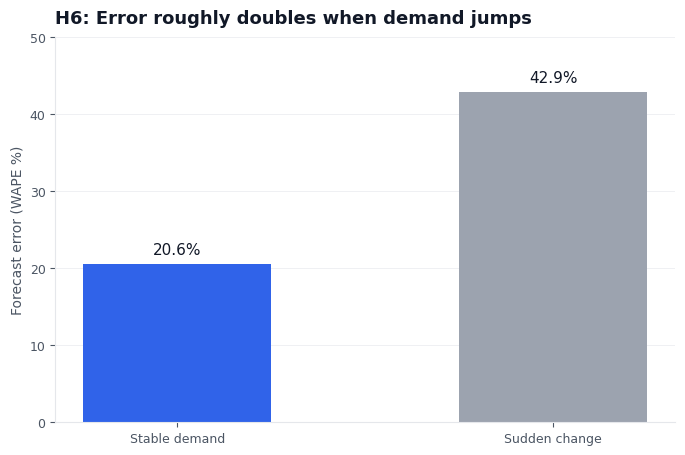

  ✓ Saved: charts/03_demand_forecasting/H6_sudden_change.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLORS['primary'], COLORS['light']]
ax.bar(h6['Condition'], h6['WAPE'], color=colors, edgecolor='none', width=0.5)
ax.set_ylim(0, 50)
style_ax(ax, title='H6: Error roughly doubles when demand jumps', ylabel='Forecast error (WAPE %)')
for i, v in enumerate(h6['WAPE']):
    ax.text(i, v + 1.2, f'{v:.1f}%', ha='center', color=COLORS['black'], fontsize=11)
save_chart(fig, 'H6_sudden_change.png')

**Interpretation — SUPPORTED**  
Stable periods ~20.6% WAPE; sudden-change periods ~42.9%. Robust across alternate thresholds and definitions. Use as a **reliability signal** for the product, not as an automatic model switch.

## Summary of findings

| Hypothesis | Result | Headline |
|------------|--------|----------|
| H1 Historical signal | **SUPPORTED** | 1-week WAPE 25.4% vs 2-week 36.7% |
| H2 Multiple periods | **NOT SUPPORTED** | Simple lag beat smoothing / MA / regression |
| H3 Calendar features | **MIXED** | Pooled slightly worse; 17/20 stores improved |
| H4 Store volume | **SUPPORTED** | Higher volume → lower median error (25.2% vs 28.0%) |
| H5 Trend-aware | **NOT SUPPORTED** | 25.4% → 33.1% WAPE |
| H6 Sudden changes | **SUPPORTED** | 20.6% stable vs 42.9% sudden |

### Overall conclusion

Weekly store-level demand forecasting is **feasible**, especially one week ahead, with a **simple historical baseline**.

Extra complexity (multi-period methods, the tested trend rule) did **not** improve overall accuracy. Calendar effects are **store-dependent**. Reliability **falls when demand jumps**.

**Answer to Q2:**  
Tiller can forecast weekly store-level demand 1–2 weeks ahead using historical patterns, but **reliability varies by store and demand conditions**.

**Product direction:**  
Simple forecast → store context → **reliability signal** → better-informed planning decision  

Next phase: translate this into an analytical MVP without assuming more model complexity is better.